In [ ]:
'''from google.colab import drive

drive.mount('/content/drive')
'''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!pip install mediapipe


In [ ]:
import numpy as np
from math import atan2, degrees

# HAMNOSYS CLASS SETS

SIGNER_CLASSES = [
    "hamextfingeru","hamextfingerur","hamextfingerr","hamextfingerdr",
    "hamextfingerd","hamextfingerul","hamextfingerl","hamextfingerdl"
]

BIRD_CLASSES = [
    "hamextfingero","hamextfingeror","hamextfingerr","hamextfingerir",
    "hamextfingeri","hamextfingerol","hamextfingerl","hamextfingeril"
]

RIGHT_CLASSES = [
    "hamextfingeru","hamextfingeruo","hamextfingero","hamextfingerdo",
    "hamextfingerd","hamextfingerui","hamextfingeri","hamextfingerdi"
]

PALM_CLASSES = [
    "hampalmu","hampalmur","hampalmr","hampalmdr",
    "hampalmd","hampalmul","hampalml","hampalmdl"
]


class ID3HandTree:

    # ---------------------- VIEW CLASSIFIER ----------------------
    def classify_view(self, wrist, eye_avg, right_shoulder):
        # wrist, eye_avg, right_shoulder are 2D (x,y)
        if wrist[1] < eye_avg[1] - 0.15:
            return "bird"
        elif wrist[0] < right_shoulder[0] - 0.05:
            return "right"
        else:
            return "signer"

    # --------------------- ANGLE CLASSIFIER ----------------------
    def angle_to_dir(self, angle):
        if 0 <= angle < 22 or 337 <= angle <= 360: return "r"
        if 22 <= angle < 67: return "ur"
        if 67 <= angle < 112: return "u"
        if 112 <= angle < 157: return "ul"
        if 157 <= angle < 202: return "l"
        if 202 <= angle < 247: return "dl"
        if 247 <= angle < 292: return "d"
        return "dr"

    # ---------------------- FINGER CLASSIFIER ----------------------
    def classify_finger(self, view, wrist, tip):

        vx = tip[0] - wrist[0]
        vy = tip[1] - wrist[1]
        vz = tip[2] - wrist[2]

        # FORCE correct outward for right-view left pointing
        if view == "right" and vx < -0.05:
            return "hamextfingero"

        # fallback original angle logic
        angle = degrees(atan2(-vy, vx)) % 360
        base_dir = self.angle_to_dir(angle)

        if vz > 0:
            tilt = "i"
        elif vz < 0:
            tilt = "o"
        else:
            tilt = ""

        candidate = f"hamextfinger{base_dir}{tilt}"

        if view == "signer":
            allowed = SIGNER_CLASSES
        elif view == "bird":
            allowed = BIRD_CLASSES
        else:
            allowed = RIGHT_CLASSES

        if candidate in allowed:
            return candidate

        fallback = f"hamextfinger{base_dir}"
        if fallback in allowed:
            return fallback

        return allowed[0]

    # ---------------------- PALM CLASSIFIER (8-DIRECTIONS) ----------------------
    def classify_palm(self, wrist, index_mcp, pinky_mcp):
        # Palm plane vectors
        v1 = index_mcp - wrist
        v2 = pinky_mcp - wrist
        normal = np.cross(v1, v2)

        # In Mediapipe:
        # x → right, y → down, z → toward camera
        # We convert to a consistent 2D system:
        nx = normal[0]
        ny = -normal[1]   # invert because screen Y is reversed

        # If vector too small → fallback
        if abs(nx) < 1e-6 and abs(ny) < 1e-6:
            return "hampalmd"

        # Compute angle in degrees
        angle = (degrees(atan2(ny, nx)) + 360) % 360

        # Map angle to 8 palm orientations
        if   337 <= angle or angle < 22:    return "hampalmr"    # right
        elif 22 <= angle < 67:              return "hampalmur"   # up-right
        elif 67 <= angle < 112:             return "hampalmu"    # up
        elif 112 <= angle < 157:            return "hampalmul"   # up-left
        elif 157 <= angle < 202:            return "hampalml"    # left
        elif 202 <= angle < 247:            return "hampalmdl"   # down-left
        elif 247 <= angle < 292:            return "hampalmd"    # down
        else:                               return "hampalmdr"   # down-right


In [ ]:
import random

tree = ID3HandTree()

def generate_synthetic():

    target_view = random.choice(["bird", "right", "signer"])

    # realistic eye position
    eye_avg = np.array([
        np.random.uniform(0.42, 0.58),
        np.random.uniform(0.18, 0.28)
    ])

    # realistic shoulder position
    right_shoulder = np.array([
        eye_avg[0] + np.random.uniform(0.08, 0.15),
        eye_avg[1] + np.random.uniform(0.20, 0.30)
    ])

    # realistic wrist for each view
    if target_view == "bird":
        # wrist clearly ABOVE eyes
        wrist = np.array([
            np.random.uniform(0.35, 0.65),
            eye_avg[1] - np.random.uniform(0.12, 0.22),
            -0.1
        ])

    elif target_view == "right":
        # wrist to the LEFT of right shoulder, around shoulder height
        wrist = np.array([
            right_shoulder[0] - np.random.uniform(0.08, 0.20),
            right_shoulder[1] - np.random.uniform(-0.05, 0.12),  # sometimes above, sometimes below
            -0.1
        ])

    else:  # signer
        # wrist to the RIGHT of right shoulder (near signer POV)
        wrist = np.array([
            right_shoulder[0] + np.random.uniform(0.05, 0.12),
            right_shoulder[1] - np.random.uniform(-0.05, 0.12),
            -0.1
        ])

    # MCPs
    index_mcp = wrist + np.array([
        np.random.uniform(0.06, 0.15),
        np.random.uniform(-0.10, 0.05),
        np.random.uniform(-0.08, 0.05)
    ])

    pinky_mcp = wrist + np.array([
        np.random.uniform(-0.15, -0.06),
        np.random.uniform(-0.10, 0.05),
        np.random.uniform(-0.08, 0.05)
    ])

    # fingertip direction
    theta = np.random.uniform(0, 2*np.pi)
    phi = np.random.uniform(-0.6, 0.6)
    r = np.random.uniform(0.15, 0.45)

    tip = wrist + np.array([
        np.cos(theta)*np.cos(phi),
        np.sin(phi),
        np.sin(theta)*np.cos(phi)
    ]) * r

    # TEACHER labels
    view_label = tree.classify_view(wrist[:2], eye_avg, right_shoulder)
    finger_label = tree.classify_finger(view_label, wrist, tip)
    palm_label = tree.classify_palm(wrist, index_mcp, pinky_mcp)

    return wrist, tip, index_mcp, pinky_mcp, eye_avg, right_shoulder, view_label, finger_label, palm_label



In [ ]:
X_view = []
y_view = []

X_finger_signer = []
y_finger_signer = []

X_finger_bird = []
y_finger_bird = []

X_finger_right = []
y_finger_right = []

X_palm = []
y_palm = []

N = 60000  # 60k synthetic

for _ in range(N):
    wrist, tip, i_mcp, p_mcp, eye, shoulder, v_lbl, f_lbl, p_lbl = generate_synthetic()

    fv_view = np.concatenate([
        wrist[:2] - eye,
        wrist[:2] - shoulder
    ])
    X_view.append(fv_view)
    y_view.append(v_lbl)

    fv_hand = np.concatenate([
        tip - wrist,
        i_mcp - wrist,
        p_mcp - wrist
    ])

    if v_lbl == "signer":
        X_finger_signer.append(fv_hand)
        y_finger_signer.append(f_lbl)

    elif v_lbl == "bird":
        X_finger_bird.append(fv_hand)
        y_finger_bird.append(f_lbl)

    else:  # right
        X_finger_right.append(fv_hand)
        y_finger_right.append(f_lbl)

    X_palm.append(fv_hand)
    y_palm.append(p_lbl)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# View encoder + model
enc_view = LabelEncoder()
y_view_enc = enc_view.fit_transform(y_view)
clf_view = RandomForestClassifier(n_estimators=350, n_jobs=-1)
clf_view.fit(X_view, y_view_enc)

# Finger (signer)
enc_finger_signer = LabelEncoder()
y_finger_signer_enc = enc_finger_signer.fit_transform(y_finger_signer)
clf_finger_signer = RandomForestClassifier(n_estimators=350, n_jobs=-1)
clf_finger_signer.fit(X_finger_signer, y_finger_signer_enc)

# Finger (bird)
enc_finger_bird = LabelEncoder()
y_finger_bird_enc = enc_finger_bird.fit_transform(y_finger_bird)
clf_finger_bird = RandomForestClassifier(n_estimators=350, n_jobs=-1)
clf_finger_bird.fit(X_finger_bird, y_finger_bird_enc)

# Finger (right)
enc_finger_right = LabelEncoder()
y_finger_right_enc = enc_finger_right.fit_transform(y_finger_right)
clf_finger_right = RandomForestClassifier(n_estimators=350, n_jobs=-1)
clf_finger_right.fit(X_finger_right, y_finger_right_enc)

# Palm model
enc_palm = LabelEncoder()
y_palm_enc = enc_palm.fit_transform(y_palm)
clf_palm = RandomForestClassifier(n_estimators=350, n_jobs=-1)
clf_palm.fit(X_palm, y_palm_enc)


RandomForestClassifier(n_estimators=350, n_jobs=-1)

In [ ]:
import joblib

joblib.dump(clf_view, "clf_view.pkl")
joblib.dump(enc_view, "enc_view.pkl")

joblib.dump(clf_finger_signer, "clf_finger_signer.pkl")
joblib.dump(enc_finger_signer, "enc_finger_signer.pkl")

joblib.dump(clf_finger_bird, "clf_finger_bird.pkl")
joblib.dump(enc_finger_bird, "enc_finger_bird.pkl")

joblib.dump(clf_finger_right, "clf_finger_right.pkl")
joblib.dump(enc_finger_right, "enc_finger_right.pkl")

joblib.dump(clf_palm, "clf_palm.pkl")
joblib.dump(enc_palm, "enc_palm.pkl")


['enc_palm.pkl']

In [ ]:
import cv2
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_pose = mp.solutions.pose

def extract_landmarks(path):
    img = cv2.imread(path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with mp_pose.Pose(static_image_mode=True) as pose:
        p_res = pose.process(rgb)

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
        h_res = hands.process(rgb)

    if not p_res.pose_landmarks or not h_res.multi_hand_landmarks:
        return None

    p = p_res.pose_landmarks.landmark
    h = h_res.multi_hand_landmarks[0].landmark

    left_eye = np.array([p[2].x,p[2].y])
    right_eye = np.array([p[5].x,p[5].y])
    eye_avg = (left_eye + right_eye)/2

    shoulder = np.array([p[12].x, p[12].y])

    wrist = np.array([h[0].x,h[0].y,h[0].z])
    tip = np.array([h[8].x,h[8].y,h[8].z])
    i_mcp = np.array([h[5].x,h[5].y,h[5].z])
    p_mcp = np.array([h[17].x,h[17].y,h[17].z])

    return wrist, tip, i_mcp, p_mcp, eye_avg, shoulder


In [ ]:
def ml_predict(path):

    L = extract_landmarks(path)
    if L is None:
        print("No landmarks detected")
        return None

    wrist, tip, i_mcp, p_mcp, eye, shoulder = L

    # ---- View features ----
    fv_view = np.concatenate([
        wrist[:2] - eye,
        wrist[:2] - shoulder
    ]).reshape(1,-1)

    view_idx = clf_view.predict(fv_view)[0]
    view = enc_view.inverse_transform([view_idx])[0]

    # ---- Hand feature ----
    fv_hand = np.concatenate([
        tip - wrist, i_mcp - wrist, p_mcp - wrist
    ]).reshape(1,-1)

    # ---- Finger based on view ----
    if view == "signer":
        f_idx = clf_finger_signer.predict(fv_hand)[0]
        finger = enc_finger_signer.inverse_transform([f_idx])[0]

    elif view == "bird":
        f_idx = clf_finger_bird.predict(fv_hand)[0]
        finger = enc_finger_bird.inverse_transform([f_idx])[0]

    else: # right
        f_idx = clf_finger_right.predict(fv_hand)[0]
        finger = enc_finger_right.inverse_transform([f_idx])[0]

    # ---- Palm ----
    p_idx = clf_palm.predict(fv_hand)[0]
    palm = enc_palm.inverse_transform([p_idx])[0]

    return view, finger, palm


In [ ]:
import tempfile
import os
import cv2

def detect_orientation(frame):
    """
    Frame-level orientation detector
    Returns (view, finger, palm)
    Safe for integration
    """

    if frame is None:
        return None

    temp_path = None

    try:
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            temp_path = tmp.name
            cv2.imwrite(temp_path, frame)

        result = ml_predict(temp_path)

        if result is None:
            return None

        view, finger, palm = result

        return (view, finger, palm)   # ✅ RETURN ALL THREE

    except Exception:
        return None

    finally:
        if temp_path and os.path.exists(temp_path):
            os.remove(temp_path)

('bird', 'hamextfingero', 'hampalmd')


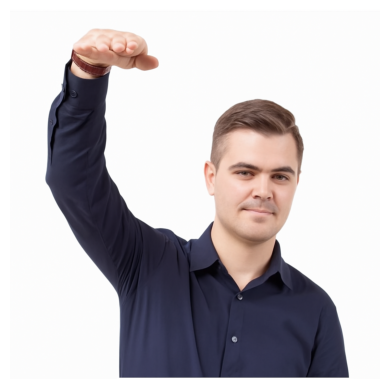

In [ ]:
#img = "/content/drive/MyDrive/ori_ima.png"
#print(ml_predict(img))
from PIL import Image
import matplotlib.pyplot as plt

#img = Image.open("/content/drive/MyDrive/ori_ima.png")
#plt.imshow(img)
#plt.axis('off')
#plt.show()


In [ ]:
from collections import Counter
import cv2

def run_orientation_module(video_path):

    views = []
    fingers = []
    palms = []

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return {"per_frame": [], "final": None}

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        result = detect_orientation(frame)

        if result is None:
            continue

        view, finger, palm = result

        views.append(view)
        fingers.append(finger)
        palms.append(palm)

    cap.release()

    if not views:
        return {"per_frame": [], "final": None}

    final_view   = Counter(views).most_common(1)[0][0]
    final_finger = Counter(fingers).most_common(1)[0][0]
    final_palm   = Counter(palms).most_common(1)[0][0]

    return {
        "per_frame": list(zip(views, fingers, palms)),
        "final": (final_view, final_finger, final_palm)
    }